In [1]:
import os, sys
from pathlib import Path
import pickle as pkl
import json, zipfile, shutil
import numpy as np
from tqdm import tqdm
from collections import defaultdict
from PIL import Image
import torch
from diffusers import FluxFillPipeline
from diffusers.utils import load_image

from nunchaku import NunchakuFluxTransformer2dModel
from nunchaku.utils import get_precision

pa_mpjpe: 49.217037200927734
mpjpe: 95.82769012451172
pve: 105.6897201538086
accel: 3.7035953998565674
wa2_mpjpe: 139.29684448242188
waa_mpjpe: 93.5020523071289
rte: 1.3221714496612549
jitter: 12.695928573608398
fs: 2.6523542404174805


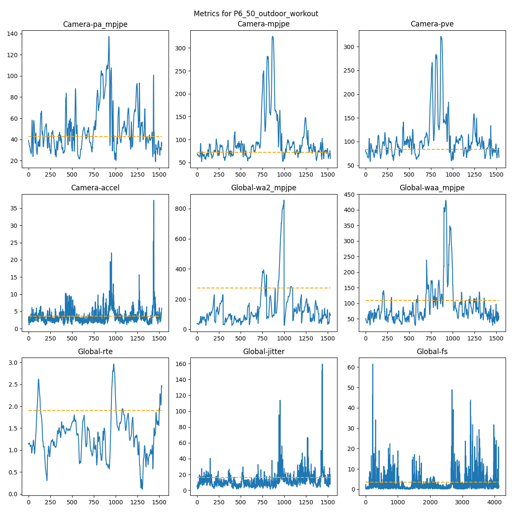

In [ ]:
dataset_dir = Path("../samples/debug/emdb_debug")
root_dir = Path("/data/datasets/emdb/")
vid = 'P6_50_outdoor_workout'

metrics = pkl.loads((dataset_dir / f"{vid}_results.pkl").read_bytes())
print("\n".join(f"{k}: {v.mean().item()}" for k,v in metrics.items()))
batch = torch.load(dataset_dir / f"{vid}_batch.pt")
vertice_sets = torch.load(dataset_dir / f"{vid}_pred_target.pt")
plot_img = Image.open(dataset_dir / f"{vid}_metrics.png")
plot_img.resize((512, 512))

In [ ]:
i = 900

category, vid_name = vid.split('_')[0], '_'.join(vid.split('_')[1:])
target_zip = zipfile.ZipFile(root_dir / f"_{category}.zip")
target_name = f"{category}/{vid_name}/images/{i:05d}.jpg"
target_zip.extract(target_name, path='outputs/')
shutil.move('outputs/' + target_name, 'tmp.png')
target_frame = Image.open("tmp.png")
target_zip.close()
target_frame

In [37]:
def mask_bbox_from_keypoints(keypoints, image_size, conf_thresh=0.85, margin=32):
    """
    keypoints: np.ndarray (N, 3) => [x, y, conf]
    image_size: (width, height)
    Returns (bbox, direction) where bbox is [x1, y1, x2, y2].
    Masks a single side (top/left/bottom/right) to cover as many
    low-confidence keypoints as possible with minimal area.
    """
    w, h = image_size
    kp = np.asarray(keypoints, dtype=np.float32)
    if kp.ndim != 2 or kp.shape[1] != 3:
        raise ValueError(f"Expected keypoints shape (N, 3), got {kp.shape}")

    low = kp[kp[:, 2] < conf_thresh]
    if low.size == 0:
        return None, None  # nothing to mask

    xs = np.clip(low[:, 0], 0, w)
    ys = np.clip(low[:, 1], 0, h)

    def choose_best(candidates):
        best = None
        for count, area, bbox, direction in candidates:
            if best is None:
                best = (count, area, bbox, direction)
                continue
            if count > best[0] or (count == best[0] and area < best[1]):
                best = (count, area, bbox, direction)
        return best

    def best_top():
        ys_sorted = np.unique(np.sort(ys))
        candidates = []
        for y_t in ys_sorted:
            count = int((ys <= y_t).sum())
            area = float(y_t) * w
            candidates.append((count, area, [0.0, 0.0, float(w), float(y_t)+margin], "top"))
        return choose_best(candidates)

    def best_bottom():
        ys_sorted = np.unique(np.sort(ys))
        candidates = []
        for y_t in ys_sorted:
            count = int((ys >= y_t).sum())
            area = float(h - y_t) * w
            candidates.append((count, area, [0.0, float(y_t)-margin, float(w), float(h)], "bottom"))
        return choose_best(candidates)

    def best_left():
        xs_sorted = np.unique(np.sort(xs))
        candidates = []
        for x_t in xs_sorted:
            count = int((xs <= x_t).sum())
            area = float(x_t) * h
            candidates.append((count, area, [0.0, 0.0, float(x_t)+margin, float(h)], "left"))
        return choose_best(candidates)

    def best_right():
        xs_sorted = np.unique(np.sort(xs))
        candidates = []
        for x_t in xs_sorted:
            count = int((xs >= x_t).sum())
            area = float(w - x_t) * h
            candidates.append((count, area, [float(x_t)-margin, 0.0, float(w), float(h)], "right"))
        return choose_best(candidates)

    candidates = [best_top(), best_bottom(), best_left(), best_right()]
    # Choose candidate with max covered points, then min area.
    count, area, bbox, direction = max(candidates, key=lambda c: (c[0], -c[1]))
    return bbox, direction

def apply_bbox_mask(image, bbox, direction, fill_color=(127, 127, 127)):
    """
    image: PIL.Image
    bbox: [x1, y1, x2, y2]
    direction: 'top' | 'bottom' | 'left' | 'right'
    Returns (canvas, mask)
    """
    w, h = image.size
    x1, y1, x2, y2 = map(int, bbox)

    # Ensure bbox is within image bounds
    x1 = max(0, min(x1, w))
    x2 = max(0, min(x2, w))
    y1 = max(0, min(y1, h))
    y2 = max(0, min(y2, h))

    # Gray canvas
    canvas = Image.new("RGB", (w, h), fill_color)

    # Paste the unmasked region (complement of the bbox side)
    if direction == "bottom":
        # keep top part
        canvas.paste(image.crop((0, 0, w, y1)), (0, 0))
        masked_box = (0, y1, w, h)
    elif direction == "top":
        # keep bottom part
        canvas.paste(image.crop((0, y2, w, h)), (0, y2))
        masked_box = (0, 0, w, y2)
    elif direction == "left":
        # keep right part
        canvas.paste(image.crop((x2, 0, w, h)), (x2, 0))
        masked_box = (0, 0, x2, h)
    elif direction == "right":
        # keep left part
        canvas.paste(image.crop((0, 0, x1, h)), (0, 0))
        masked_box = (x1, 0, w, h)
    else:
        raise ValueError(f"Unknown direction: {direction}")

    # Create mask: black in masked region, white elsewhere
    mask = Image.new("L", (w, h), 0)
    mx1, my1, mx2, my2 = masked_box
    mask.paste(Image.new("L", (mx2 - mx1, my2 - my1), 255), (mx1, my1))

    return canvas, mask



In [ ]:
import cv2

color_schemes = {
    "red": ([255, 168, 154], [153, 17, 1]),
    "green": ([183, 255, 191], [0, 171, 8]),
    "blue": ([183, 255, 255], [0, 0, 255]),
    "cyan": ([183, 255, 255], [0, 255, 255]),
    "magenta": ([255, 183, 255], [255, 0, 255]),
    "black": ([0, 0, 0], [0, 0, 0]),
    "orange": ([255, 183, 0], [255, 128, 0]),
    "grey": ([203, 203, 203], [203, 203, 203]),
}

def get_colors_by_conf(conf, low="red", high="green"):
    colors = torch.stack([conf] * 3, dim=-1)
    colors = colors * torch.tensor(color_schemes[high][1]) + (1 - colors) * torch.tensor(color_schemes[low][1])
    return colors

def draw_kpts_with_conf(frame, kp2d, conf, thickness=2):
    """
    Args:
        kp2d: (J, 2),
        conf: (J,)
    """
    frame_ = frame.copy()
    conf = conf.reshape(-1)
    colors = get_colors_by_conf(conf)  # (J, 3)
    colors = colors[:, [2, 1, 0]].int().numpy().tolist()
    for j in range(kp2d.shape[0]):
        x, y = kp2d[j, :2]
        c = colors[j]
        cv2.circle(frame_, (int(x), int(y)), thickness, c, -1)
    return frame_

frame_marked = draw_kpts_with_conf(np.array(target_frame), batch['kp2d'][i,:,:2], batch['kp2d'][i,:,2], thickness=8)
Image.fromarray(frame_marked)

In [38]:
width, height = int(batch['K_fullimg'][0,0,2].item() * 2), int(batch['K_fullimg'][0,1,2].item() * 2)
bbox, direction = mask_bbox_from_keypoints(batch['kp2d'][i].numpy(), (width, height))
canvas, mask = apply_bbox_mask(target_frame, bbox, direction)
print(bbox, direction)

[0.0, 997.655517578125, 1440.0, 1920.0] bottom


In [18]:
# image = load_image("https://huggingface.co/datasets/diffusers/diffusers-images-docs/resolve/main/cup.png")
# mask = load_image("https://huggingface.co/datasets/diffusers/diffusers-images-docs/resolve/main/cup_mask.png")

precision = get_precision()  # auto-detect your precision is 'int4' or 'fp4' based on your GPU
transformer = NunchakuFluxTransformer2dModel.from_pretrained(
    f"nunchaku-tech/nunchaku-flux.1-fill-dev/svdq-int4_r32-flux.1-fill-dev.safetensors"
)
pipe = FluxFillPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-Fill-dev", transformer=transformer, torch_dtype=torch.bfloat16
).to("cuda")

[2026-02-03 16:00:18.943] [info] Initializing QuantizedFluxModel on device 0
Injecting quantized module
[2026-02-03 16:00:19.127] [info] Loading partial weights from pytorch
[2026-02-03 16:00:19.858] [info] Done.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


  0%|          | 0/50 [00:00<?, ?it/s]

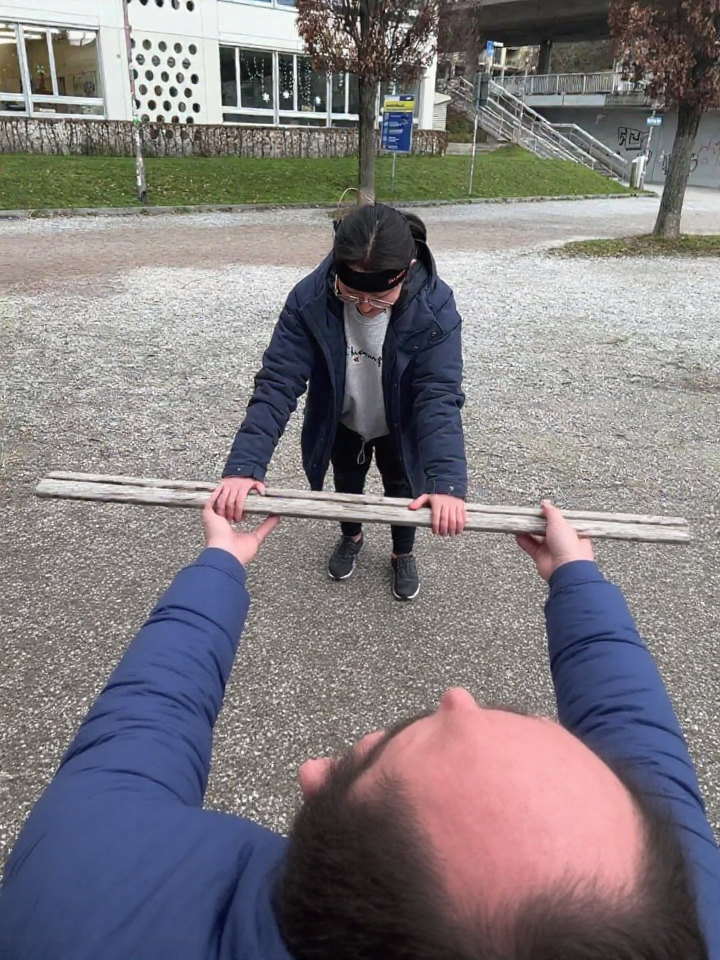

In [50]:
image = pipe(
    prompt="Full-bodied human",
    image=canvas.resize((width // 2, height // 2)),
    mask_image=mask.resize((width // 2, height // 2)),
    height=height // 2,
    width=width // 2,
    guidance_scale=30,
    num_inference_steps=50,
    max_sequence_length=512,
).images[0]
image